In [1]:
import sys
sys.path.insert(0, '../..')

import warnings
warnings.filterwarnings('ignore')

import os
import io
import time
import json
import joblib
import requests
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from tqdm import tqdm

import clip
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    NamedVector, Filter, FieldCondition,
    MatchValue, HnswConfigDiff,
    OptimizersConfigDiff
)
from sentence_transformers import SentenceTransformer

from src.utils.config import settings

device = 'cuda' if torch.cuda.is_available() \
         else 'cpu'

PROC        = '../../data/processed/'
FEAT        = '../../data/features/'
POSTER_DIR  = Path('../../data/posters')
POSTER_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Imports ready")
print(f"   Device  : {device}")
print(f"   PyTorch : {torch.__version__}")

✅ Imports ready
   Device  : cpu
   PyTorch : 2.3.0


In [2]:
# Load CLIP Model

print("Loading CLIP model...")
print("First run downloads ~350MB\n")

# ViT-B/32 — good balance of speed and quality
# ViT-L/14 — better quality, slower
CLIP_MODEL = "ViT-B/32"

start = time.time()
clip_model, clip_preprocess = clip.load(
    CLIP_MODEL, device=device)
clip_model.eval()
elapsed = time.time() - start

# CLIP embedding dimension
CLIP_DIM = clip_model.visual.output_dim

print(f"✅ CLIP loaded in {elapsed:.1f}s")
print(f"   Model    : {CLIP_MODEL}")
print(f"   CLIP dim : {CLIP_DIM}")
print(f"   Device   : {device}")

# Quick test
test_text  = clip.tokenize(
    ["a dark thriller movie"]).to(device)
with torch.no_grad():
    test_emb = clip_model.encode_text(test_text)
    test_emb = F.normalize(test_emb, dim=-1)
print(f"   Test emb : {test_emb.shape} ✅")

Loading CLIP model...
First run downloads ~350MB



100%|███████████████████████████████████████| 338M/338M [00:26<00:00, 13.6MiB/s]


✅ CLIP loaded in 28.9s
   Model    : ViT-B/32
   CLIP dim : 512
   Device   : cpu
   Test emb : torch.Size([1, 512]) ✅


In [4]:
#Load Data + Links
movies = pd.read_csv(
    PROC + 'movies_master.csv',
    low_memory=False)
links  = pd.read_csv(
    PROC + 'links_cleaned.csv')

import ast
def safe_parse(val):
    try:
        r = ast.literal_eval(str(val))
        return r if isinstance(r, list) else []
    except:
        return []

movies['genres_list'] = movies['genres_list']\
    .apply(safe_parse)

# Fill text fields
for col in ['title', 'overview',
            'tagline', 'director']:
    movies[col] = movies[col].fillna('')

# Only movies with movieId
movies = movies[movies['movieId'].notna()].copy()
movies['movieId'] = movies['movieId'].astype(int)

# Check what columns already exist
print(f"Movies columns: {list(movies.columns)}")
print(f"Links columns : {list(links.columns)}")

# movies_master already has 'id' = tmdbId
# and 'tmdbId' from the Day 3 merge
# Check which one exists
if 'tmdbId' in movies.columns:
    print("\n✅ tmdbId column already exists in movies")
    movies['tmdbId'] = pd.to_numeric(
        movies['tmdbId'], errors='coerce')

elif 'id' in movies.columns:
    print("\n✅ Using 'id' column as tmdbId")
    movies['tmdbId'] = pd.to_numeric(
        movies['id'], errors='coerce')

else:
    print("\nMerging links to get tmdbId...")
    links['tmdbId'] = pd.to_numeric(
        links['tmdbId'], errors='coerce')
    links = links.dropna(subset=['tmdbId'])
    links['tmdbId'] = links['tmdbId'].astype(int)

    movies = movies.merge(
        links[['movieId', 'tmdbId']],
        on='movieId', how='left'
    )

print(f"\nMovies          : {len(movies):,}")
print(f"With tmdbId     : "
      f"{movies['tmdbId'].notna().sum():,}")
print(f"Without tmdbId  : "
      f"{movies['tmdbId'].isna().sum():,}")
print(f"\nSample:")
print(movies[['movieId', 'tmdbId', 'title']]\
      .head(3))

Movies columns: ['id', 'title', 'original_title', 'overview', 'tagline', 'genres', 'release_date', 'year', 'original_language', 'budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity', 'production_companies', 'poster_path', 'imdb_id', 'cast_names', 'director', 'keyword_list', 'movieId', 'tmdbId', 'genres_list']
Links columns : ['movieId', 'imdbId', 'tmdbId']

✅ tmdbId column already exists in movies

Movies          : 45,454
With tmdbId     : 45,454
Without tmdbId  : 0

Sample:
   movieId  tmdbId             title
0        1     862         Toy Story
1        2    8844           Jumanji
2        3   15602  Grumpier Old Men


In [5]:
# Fetch Posters From TMDB

In [6]:
TMDB_KEY      = settings.TMDB_API_KEY
TMDB_BASE     = settings.TMDB_BASE_URL
TMDB_IMG_BASE = "https://image.tmdb.org/t/p/w342"

def fetch_poster(tmdb_id: int,
                 save_dir: Path,
                 session: requests.Session
                 ) -> str | None:
    """
    Fetch movie poster from TMDB API.
    Returns local file path or None if failed.
    """
    save_path = save_dir / f"{tmdb_id}.jpg"

    # Already downloaded — skip
    if save_path.exists():
        return str(save_path)

    try:
        # Get movie details from TMDB
        url      = f"{TMDB_BASE}/movie/{tmdb_id}"
        response = session.get(
            url,
            params  = {"api_key": TMDB_KEY},
            timeout = 10
        )

        if response.status_code != 200:
            return None

        data         = response.json()
        poster_path  = data.get('poster_path')

        if not poster_path:
            return None

        # Download poster image
        img_url  = f"{TMDB_IMG_BASE}{poster_path}"
        img_resp = session.get(
            img_url, timeout=10)

        if img_resp.status_code != 200:
            return None

        # Save locally
        with open(save_path, 'wb') as f:
            f.write(img_resp.content)

        return str(save_path)

    except Exception:
        return None


# Fetch posters for movies with tmdbId
# Use a sample for speed — 1000 movies
movies_with_tmdb = movies[
    movies['tmdbId'].notna()
].copy()
movies_with_tmdb['tmdbId'] = \
    movies_with_tmdb['tmdbId'].astype(int)

# Sample 1000 movies for poster fetching
# (fetching all 9K would take too long)
POSTER_SAMPLE = 1000
sample_movies = movies_with_tmdb.head(
    POSTER_SAMPLE)

print(f"Fetching posters for "
      f"{len(sample_movies):,} movies...")
print(f"Saving to: {POSTER_DIR}\n")

session    = requests.Session()
poster_map = {}   # tmdbId → local path
failed     = 0

for _, row in tqdm(
        sample_movies.iterrows(),
        total=len(sample_movies),
        desc="Fetching posters"):

    tmdb_id = int(row['tmdbId'])
    path    = fetch_poster(
        tmdb_id, POSTER_DIR, session)

    if path:
        poster_map[tmdb_id] = path
    else:
        failed += 1

    # Rate limit — TMDB allows 40 req/s
    time.sleep(0.03)

print(f"\n✅ Poster fetching complete")
print(f"   Downloaded : {len(poster_map):,}")
print(f"   Failed     : {failed:,}")
print(f"   Success %  : "
      f"{len(poster_map)/len(sample_movies)*100:.1f}%")

# Save poster map
joblib.dump(poster_map,
    FEAT + 'poster_map.joblib')

Fetching posters for 1,000 movies...
Saving to: ../../data/posters



Fetching posters: 100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:18<00:00,  7.20it/s]


✅ Poster fetching complete
   Downloaded : 991
   Failed     : 6
   Success %  : 99.1%


['../../data/features/poster_map.joblib']

In [7]:
#Encode Posters With CLIP

def encode_poster(image_path: str,
                  model,
                  preprocess,
                  device: str) -> np.ndarray | None:
    """
    Encode a movie poster image with CLIP.
    Returns normalised embedding vector.
    """
    try:
        image = Image.open(image_path)\
            .convert('RGB')
        image_input = preprocess(image)\
            .unsqueeze(0).to(device)

        with torch.no_grad():
            emb = model.encode_image(image_input)
            emb = F.normalize(emb, dim=-1)

        return emb.cpu().numpy()[0]

    except Exception as e:
        return None


print(f"Encoding {len(poster_map):,} "
      f"posters with CLIP {CLIP_MODEL}...")

clip_image_embeddings = {}
failed_encode         = 0

for tmdb_id, path in tqdm(
        poster_map.items(),
        desc="Encoding posters"):

    emb = encode_poster(
        path, clip_model,
        clip_preprocess, device)

    if emb is not None:
        clip_image_embeddings[tmdb_id] = emb
    else:
        failed_encode += 1

print(f"\n✅ Poster encoding complete")
print(f"   Encoded  : "
      f"{len(clip_image_embeddings):,}")
print(f"   Failed   : {failed_encode:,}")
print(f"   Emb dim  : {CLIP_DIM}")

# Save image embeddings
np.save(
    FEAT + 'clip_image_embeddings.npy',
    np.array(list(
        clip_image_embeddings.values()))
)
joblib.dump(
    {k: i for i, k in enumerate(
        clip_image_embeddings.keys())},
    FEAT + 'clip_tmdbid_to_idx.joblib'
)

print(f"✅ CLIP image embeddings saved")

Encoding 991 posters with CLIP ViT-B/32...


Encoding posters: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 991/991 [00:35<00:00, 28.20it/s]


✅ Poster encoding complete
   Encoded  : 991
   Failed   : 0
   Emb dim  : 512
✅ CLIP image embeddings saved


In [8]:
# Encode Text With CLIP
def encode_text_clip(texts: list,
                     model,
                     device: str,
                     batch_size: int = 256
                     ) -> np.ndarray:
    """
    Encode text descriptions with CLIP.
    Returns normalised embeddings.
    """
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # CLIP has 77 token limit — truncate
        tokens = clip.tokenize(
            batch, truncate=True).to(device)

        with torch.no_grad():
            emb = model.encode_text(tokens)
            emb = F.normalize(emb, dim=-1)

        all_embeddings.append(
            emb.cpu().numpy())

    return np.vstack(all_embeddings)


# Encode text descriptions for all movies
# that have poster embeddings
movies_with_posters = movies[
    movies['tmdbId'].isin(
        clip_image_embeddings.keys())
].copy()

print(f"Encoding text for "
      f"{len(movies_with_posters):,} movies...")

# Build text for each movie
clip_texts = []
for _, row in movies_with_posters.iterrows():
    title   = row['title'] or ''
    genres  = ' '.join(row['genres_list'][:3]) \
              if row['genres_list'] else ''
    overview = str(row.get('overview', ''))[:200]
    text    = f"{title}. {genres}. {overview}"
    clip_texts.append(text)

clip_text_embeddings = encode_text_clip(
    clip_texts, clip_model, device)

print(f"✅ Text embeddings encoded")
print(f"   Shape : {clip_text_embeddings.shape}")
print(f"   Norm  : "
      f"{np.linalg.norm(clip_text_embeddings[0]):.4f}")

# Save
np.save(FEAT + 'clip_text_embeddings.npy',
        clip_text_embeddings)

Encoding text for 994 movies...
✅ Text embeddings encoded
   Shape : (994, 512)
   Norm  : 1.0000


In [9]:
#Fused CLIP Embeddings
def fuse_embeddings(image_emb: np.ndarray,
                    text_emb: np.ndarray,
                    alpha: float = 0.6
                    ) -> np.ndarray:
    """
    Fuse image + text embeddings.
    alpha = weight for image (visual signal)
    1-alpha = weight for text

    alpha=0.6 → slightly favour visual
    Tunable hyperparameter
    """
    fused = alpha * image_emb + \
            (1 - alpha) * text_emb
    # Renormalise after fusion
    norms = np.linalg.norm(
        fused, axis=-1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    return fused / norms


# Align embeddings — same order
tmdb_ids_ordered = [
    tmdb_id
    for tmdb_id in clip_image_embeddings.keys()
    if tmdb_id in dict(
        zip(movies_with_posters['tmdbId'],
            range(len(movies_with_posters))))
]

image_matrix = np.array([
    clip_image_embeddings[t]
    for t in tmdb_ids_ordered
])

# Fuse
fused_embeddings = fuse_embeddings(
    image_matrix,
    clip_text_embeddings[:len(image_matrix)],
    alpha=0.6
)

print(f"✅ Fused embeddings computed")
print(f"   Image weight  : 0.6")
print(f"   Text weight   : 0.4")
print(f"   Output shape  : {fused_embeddings.shape}")
print(f"   Output norm   : "
      f"{np.linalg.norm(fused_embeddings[0]):.4f}")

np.save(FEAT + 'clip_fused_embeddings.npy',
        fused_embeddings)
joblib.dump(
    tmdb_ids_ordered,
    FEAT + 'clip_tmdb_ids_ordered.joblib'
)

✅ Fused embeddings computed
   Image weight  : 0.6
   Text weight   : 0.4
   Output shape  : (991, 512)
   Output norm   : 1.0000


['../../data/features/clip_tmdb_ids_ordered.joblib']

In [10]:
# Add CLIP Vectors To Qdrant
client = QdrantClient(
    host=settings.QDRANT_HOST,
    port=settings.QDRANT_PORT)

CLIP_COLLECTION = "movies_clip"

# Create new collection for CLIP vectors
if client.collection_exists(CLIP_COLLECTION):
    client.delete_collection(CLIP_COLLECTION)

client.create_collection(
    collection_name = CLIP_COLLECTION,
    vectors_config  = {
        "clip_fused": VectorParams(
            size     = CLIP_DIM,
            distance = Distance.COSINE,
        ),
        "clip_image": VectorParams(
            size     = CLIP_DIM,
            distance = Distance.COSINE,
        ),
        "clip_text": VectorParams(
            size     = CLIP_DIM,
            distance = Distance.COSINE,
        ),
    },
    hnsw_config = HnswConfigDiff(
        m=16, ef_construct=100),
    optimizers_config = OptimizersConfigDiff(
        indexing_threshold=0),
)

print(f"✅ CLIP collection created")

# Upload CLIP vectors
tmdb_to_movie = dict(zip(
    movies['tmdbId'].astype('Int64'),
    movies['movieId']
))
tmdb_to_title = dict(zip(
    movies['tmdbId'].astype('Int64'),
    movies['title']
))
tmdb_to_genres = dict(zip(
    movies['tmdbId'].astype('Int64'),
    movies['genres_list']
))

points    = []
BATCH_SZ  = 100

for idx, tmdb_id in enumerate(tmdb_ids_ordered):
    points.append(PointStruct(
        id      = idx,
        payload = {
            "tmdb_id":  int(tmdb_id),
            "movie_id": int(tmdb_to_movie.get(
                            tmdb_id, 0)),
            "title":    str(tmdb_to_title.get(
                            tmdb_id, '')),
            "genres":   tmdb_to_genres.get(
                            tmdb_id, []),
        },
        vector  = {
            "clip_fused": fused_embeddings[
                idx].tolist(),
            "clip_image": image_matrix[
                idx].tolist(),
            "clip_text":  clip_text_embeddings[
                idx].tolist(),
        }
    ))

    if len(points) >= BATCH_SZ:
        client.upsert(
            collection_name = CLIP_COLLECTION,
            points          = points,
            wait            = True,
        )
        points = []

if points:
    client.upsert(
        collection_name = CLIP_COLLECTION,
        points          = points,
        wait            = True,
    )

info = client.get_collection(CLIP_COLLECTION)
print(f"✅ CLIP vectors uploaded")
print(f"   Points : {info.points_count:,}")
print(f"   Vectors: clip_fused + "
      f"clip_image + clip_text")

✅ CLIP collection created
✅ CLIP vectors uploaded
   Points : 991
   Vectors: clip_fused + clip_image + clip_text


In [11]:
# Text-To-Visual Search
def clip_text_search(query: str,
                     top_k: int = 10,
                     vector_type: str = "clip_fused"
                     ) -> pd.DataFrame:
    """
    Search movies using CLIP text query.
    Finds visually + semantically matching movies.

    vector_type options:
      clip_fused → image + text combined
      clip_image → visual similarity only
      clip_text  → CLIP text only
    """
    # Encode query with CLIP
    tokens = clip.tokenize(
        [query], truncate=True).to(device)

    with torch.no_grad():
        query_emb = clip_model.encode_text(tokens)
        query_emb = F.normalize(
            query_emb, dim=-1)
    query_vec = query_emb.cpu().numpy()[0].tolist()

    results = client.search(
        collection_name = CLIP_COLLECTION,
        query_vector    = NamedVector(
            name   = vector_type,
            vector = query_vec,
        ),
        limit        = top_k,
        with_payload = True,
    )

    return pd.DataFrame([{
        'title':  r.payload['title'],
        'score':  round(r.score, 4),
        'genres': r.payload['genres'],
        'type':   vector_type,
    } for r in results])


# Test text-to-visual search
print("TEXT → VISUAL SEARCH (CLIP)")
print("=" * 55)

clip_queries = [
    "dark atmospheric noir film",
    "bright colorful animated adventure",
    "epic war battle scenes",
    "romantic sunset beach scene",
]

for q in clip_queries:
    print(f"\nQuery: '{q}'")
    results = clip_text_search(q, top_k=5)
    print(results[['title', 'score',
                   'genres']].to_string(
                       index=False))

TEXT → VISUAL SEARCH (CLIP)

Query: 'dark atmospheric noir film'
               title  score                               genres
Angel and the Badman 0.6109                   [Romance, Western]
               Flirt 0.6077                     [Drama, Romance]
            Dead Man 0.6022            [Drama, Fantasy, Western]
Death and the Maiden 0.6019           [Drama, Thriller, Mystery]
        Lost Horizon 0.5997 [Adventure, Fantasy, Drama, Mystery]

Query: 'bright colorful animated adventure'
                                                 title  score                               genres
                                          Lost Horizon 0.5600 [Adventure, Fantasy, Drama, Mystery]
                                      Oliver & Company 0.5546          [Animation, Comedy, Family]
The Land Before Time III: The Time of the Great Giving 0.5535       [Animation, Adventure, Family]
                                   A Very Brady Sequel 0.5523                             [Comedy]
     

In [12]:
# Image-To-Image Search
def find_visually_similar(tmdb_id: int,
                          top_k: int = 10
                          ) -> pd.DataFrame:
    """
    Find movies with visually similar posters.
    Uses image embedding directly.
    """
    if tmdb_id not in clip_image_embeddings:
        return pd.DataFrame()

    query_vec = clip_image_embeddings[
        tmdb_id].tolist()

    results = client.search(
        collection_name = CLIP_COLLECTION,
        query_vector    = NamedVector(
            name   = "clip_image",
            vector = query_vec,
        ),
        limit        = top_k + 1,  # +1 to skip self
        with_payload = True,
    )

    # Filter out the query movie itself
    return pd.DataFrame([{
        'title':  r.payload['title'],
        'score':  round(r.score, 4),
        'genres': r.payload['genres'],
    } for r in results
      if r.payload['tmdb_id'] != tmdb_id
    ][:top_k])


# Test image-to-image search
print("IMAGE → IMAGE SEARCH (visual similarity)")
print("=" * 55)

# Pick a well-known movie
sample = movies_with_posters[
    movies_with_posters['title'].str.contains(
        'Toy Story', case=False, na=False)
].head(1)

if not sample.empty:
    tmdb_id = int(sample['tmdbId'].values[0])
    title   = sample['title'].values[0]
    print(f"\nMovies visually similar to: '{title}'")
    similar = find_visually_similar(tmdb_id, 8)
    print(similar[['title', 'score',
                   'genres']].to_string(
                       index=False))
else:
    # Use first available movie
    tmdb_id = tmdb_ids_ordered[0]
    title   = tmdb_to_title.get(tmdb_id, 'Unknown')
    print(f"\nMovies visually similar to: '{title}'")
    similar = find_visually_similar(tmdb_id, 8)
    print(similar[['title', 'score',
                   'genres']].to_string(
                       index=False))

IMAGE → IMAGE SEARCH (visual similarity)

Movies visually similar to: 'Toy Story'
                 title  score                                                   genres
         The Lion King 0.7794                               [Family, Animation, Drama]
               Aladdin 0.7756 [Animation, Family, Comedy, Adventure, Fantasy, Romance]
         A Goofy Movie 0.7708          [Romance, Animation, Family, Comedy, Adventure]
       The Flintstones 0.7604                                [Fantasy, Comedy, Family]
  Beauty and the Beast 0.7541             [Romance, Family, Animation, Fantasy, Music]
      Oliver & Company 0.7507                              [Animation, Comedy, Family]
        Batman Forever 0.7494                                 [Action, Crime, Fantasy]
The Sword in the Stone 0.7457                                      [Animation, Family]


In [13]:
# Cold Start Solution Demo
print("COLD START SOLUTION DEMO")
print("=" * 55)
print("""
Problem: New movie just released
  → 0 ratings (CF/SVD cannot find it)
  → But it HAS a poster image
  → CLIP can retrieve it via visual similarity

Simulation: take a movie, pretend it has
no ratings, show CLIP can still retrieve it
""")

# Pick a movie from our CLIP collection
# Simulate it as "new" with no ratings
test_tmdb_id = tmdb_ids_ordered[5]
test_title   = tmdb_to_title.get(
    test_tmdb_id, 'Unknown')
test_genres  = tmdb_to_genres.get(
    test_tmdb_id, [])

print(f"'New' movie (simulated cold start):")
print(f"  Title  : {test_title}")
print(f"  Genres : {test_genres}")
print(f"  Ratings: 0 (new release)")
print(f"  Poster : available ✅")

print(f"\nCF/SVD result    : ❌ Cannot recommend")
print(f"  → No interaction history")
print(f"  → Not in user-item matrix")

print(f"\nCLIP result:")
similar_cold = find_visually_similar(
    test_tmdb_id, top_k=5)
if not similar_cold.empty:
    print(f"  → Found {len(similar_cold)} "
          f"similar movies via poster:")
    print(similar_cold[['title', 'score']]\
          .to_string(index=False))
else:
    print("  → No similar movies found")

print(f"""
CONCLUSION FOR REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLIP directly solves cold start for new items:
  CF/SVD/GRank → need interaction history → fail
  CLIP          → needs only poster image  → works

This is why Pinterest and TikTok use visual
embeddings for new content retrieval.
""")

COLD START SOLUTION DEMO

Problem: New movie just released
  → 0 ratings (CF/SVD cannot find it)
  → But it HAS a poster image
  → CLIP can retrieve it via visual similarity

Simulation: take a movie, pretend it has
no ratings, show CLIP can still retrieve it

'New' movie (simulated cold start):
  Title  : Heat
  Genres : ['Action', 'Crime', 'Drama', 'Thriller']
  Ratings: 0 (new release)
  Poster : available ✅

CF/SVD result    : ❌ Cannot recommend
  → No interaction history
  → Not in user-item matrix

CLIP result:
  → Found 5 similar movies via poster:
        title  score
 Sudden Death 0.7646
     The Rock 0.7450
    True Lies 0.7365
Kiss of Death 0.7354
    City Hall 0.7319

CONCLUSION FOR REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLIP directly solves cold start for new items:
  CF/SVD/GRank → need interaction history → fail
  CLIP          → needs only poster image  → works

This is why Pinterest and TikTok use visual
embeddings for new content retrieval.



In [15]:
# Compare All Retrieval Methods
import scipy.sparse as sp
print("COMPLETE RETRIEVAL COMPARISON")
print("=" * 60)
print("Query: 'suspenseful psychological mystery'\n")

query = "suspenseful psychological mystery"

# 1. TF-IDF (Day 4)
tfidf_day4     = joblib.load(
    FEAT + 'tfidf_vectorizer.joblib')
tfidf_mat_day4 = sp.load_npz(
    FEAT + 'tfidf_matrix.npz')


q_vec = tfidf_day4.transform([query])
sims  = (tfidf_mat_day4 @ q_vec.T)\
    .toarray().flatten()
top5  = np.argsort(sims)[::-1][:5]

print("1. TF-IDF keyword (Day 4 baseline):")
for i in top5:
    print(f"   {movies.iloc[i]['title']:<40} "
          f"{sims[i]:.4f}")

# 2. e5-large dense (Day 11)
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer(
    'intfloat/e5-large-v2', device=device)
dense_client = QdrantClient(
    host=settings.QDRANT_HOST,
    port=settings.QDRANT_PORT)

q_emb = embedder.encode(
    [f"query: {query}"],
    normalize_embeddings=True)[0].tolist()

dense_res = dense_client.search(
    collection_name = "movies_hybrid",
    query_vector    = NamedVector(
        name="dense", vector=q_emb),
    limit=5, with_payload=True)

print(f"\n2. e5-large dense semantic (Day 11):")
for r in dense_res:
    print(f"   {r.payload['title']:<40} "
          f"{r.score:.4f}")

# 3. CLIP text-to-visual (Day 12)
print(f"\n3. CLIP multimodal (Day 12):")
clip_res = clip_text_search(query, top_k=5)
for _, row in clip_res.iterrows():
    print(f"   {row['title']:<40} "
          f"{row['score']:.4f}")

print(f"""
KEY DIFFERENCES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TF-IDF    → matches exact words in text
e5-large  → matches meaning in text
CLIP      → matches meaning across text AND images
            can find movies even with no text
            using visual similarity alone

Each method catches different relevant movies
→ combining them (Week 5 re-ranking) gives
  the best overall retrieval quality
""")

COMPLETE RETRIEVAL COMPARISON
Query: 'suspenseful psychological mystery'

1. TF-IDF keyword (Day 4 baseline):
   Sorry for the Disturbance                0.2811
   Ulak                                     0.2594
   The Headless Woman                       0.2526
   Confessions                              0.2395
   The Experiment                           0.2361

2. e5-large dense semantic (Day 11):
   Urban Ghost Story                        0.7864
   Clinical                                 0.7848
   Camera Obscura                           0.7832
   2:13                                     0.7818
   Successive Slidings of Pleasure          0.7817

3. CLIP multimodal (Day 12):
   Lost Horizon                             0.6383
   Power 98                                 0.6234
   Death and the Maiden                     0.6189
   Notorious                                0.6149
   Flirt                                    0.6143

KEY DIFFERENCES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Visualising poster retrieval results...


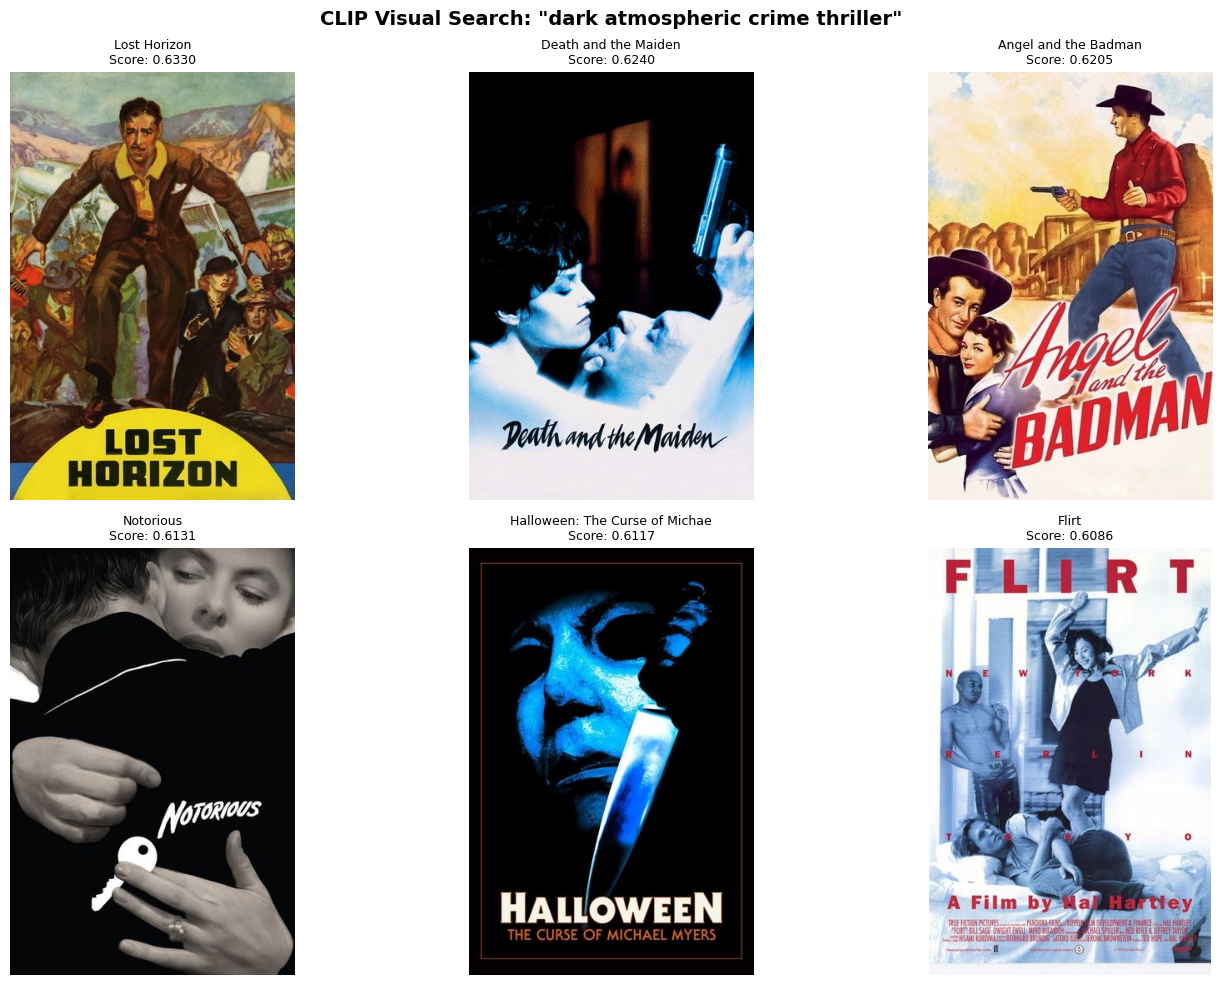

✅ Poster visualisation saved


In [16]:
# Visualise Posters
print("Visualising poster retrieval results...")

query      = "dark atmospheric crime thriller"
results_df = clip_text_search(query, top_k=6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes      = axes.flatten()
fig.suptitle(
    f'CLIP Visual Search: "{query}"',
    fontsize=14, fontweight='bold')

for i, (_, row) in enumerate(
        results_df.iterrows()):
    ax = axes[i]

    # Find tmdb_id for this title
    match = movies_with_posters[
        movies_with_posters['title'] == row['title']
    ]

    if not match.empty:
        tmdb_id = int(match['tmdbId'].values[0])
        poster_path = poster_map.get(tmdb_id)

        if poster_path and os.path.exists(
                poster_path):
            img = Image.open(poster_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'No poster',
                    ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_facecolor('#2a2a2a')
    else:
        ax.text(0.5, 0.5, 'No poster',
                ha='center', va='center',
                transform=ax.transAxes)
        ax.set_facecolor('#2a2a2a')

    ax.set_title(
        f"{row['title'][:30]}\n"
        f"Score: {row['score']:.4f}",
        fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(
    '../../data/processed/plots/'
    '09_clip_retrieval.png',
    bbox_inches='tight', dpi=100)
plt.show()
print("✅ Poster visualisation saved")

In [17]:
# Save Results + MLflow
import mlflow

clip_results = {
    "model":           f"CLIP {CLIP_MODEL}",
    "clip_dim":        CLIP_DIM,
    "n_movies_indexed":len(tmdb_ids_ordered),
    "poster_success":  len(poster_map),
    "fusion_alpha":    0.6,
    "collections": {
        "movies_hybrid": "text hybrid search",
        "movies_clip":   "visual search",
    },
    "cold_start":      "solved via poster embedding",
}

with open(PROC + 'clip_results.json', 'w') as f:
    json.dump(clip_results, f, indent=2)

# Log to MLflow
mlflow.set_tracking_uri(settings.MLFLOW_TRACKING_URI)
mlflow.set_experiment(settings.MLFLOW_EXPERIMENT_NAME)

with mlflow.start_run(run_name="CLIP_multimodal"):
    mlflow.log_params({
        "clip_model":    CLIP_MODEL,
        "clip_dim":      CLIP_DIM,
        "fusion_alpha":  0.6,
        "n_posters":     len(poster_map),
        "n_indexed":     len(tmdb_ids_ordered),
    })
    mlflow.log_metric(
        "poster_success_rate",
        len(poster_map) / len(sample_movies)
    )

print("✅ CLIP results saved")
print("✅ MLflow logged")
print(json.dumps(clip_results, indent=2))

✅ CLIP results saved
✅ MLflow logged
{
  "model": "CLIP ViT-B/32",
  "clip_dim": 512,
  "n_movies_indexed": 991,
  "poster_success": 991,
  "fusion_alpha": 0.6,
  "collections": {
    "movies_hybrid": "text hybrid search",
    "movies_clip": "visual search"
  },
  "cold_start": "solved via poster embedding"
}


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [19]:
import joblib
from pathlib import Path

POSTER_DIR = Path('../../data/posters')

# Rebuild poster_map from saved poster files
poster_map = {}
for poster_file in POSTER_DIR.glob('*.jpg'):
    tmdb_id = int(poster_file.stem)
    poster_map[tmdb_id] = str(poster_file)

print(f"✅ poster_map rebuilt: "
      f"{len(poster_map):,} posters")

joblib.dump(
    poster_map,
    '../../data/features/poster_map.joblib'
)
print("✅ poster_map saved")

✅ poster_map rebuilt: 991 posters
✅ poster_map saved
